In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# ─────────────────────────────
# Load data
# ─────────────────────────────
chess = pd.read_csv("../data/raw/chess_games.csv")
registry = pd.read_csv("../data/raw/player_registry.csv")


In [3]:
# ─────────────────────────────
# Merge datasets
# ─────────────────────────────
merged = pd.merge(
    chess[['game_id', 'white_id', 'white_rating', 'winner', 'rated', 'turns']],
    registry.rename(columns={'username': 'white_id'}),
    on='white_id',
    how='left'
)

In [4]:
# ─────────────────────────────
# Q16 — Missing registry entries
# ─────────────────────────────
q16 = merged['country'].isnull().sum()

In [5]:
# ─────────────────────────────
# Q17 — Country inconsistencies (before cleaning)
# ─────────────────────────────
q17 = merged['country'].nunique()


In [7]:
# ─────────────────────────────
# Standardize countries
# ─────────────────────────────
country_map = {
    'RUS': 'Russia',
    'US': 'United States',
    'USA': 'United States',
    'united states': 'United States',
    'UA': 'Ukraine',
    'GB': 'United Kingdom'
}
merged['country'] = merged['country'].map(country_map).fillna(merged['country'])


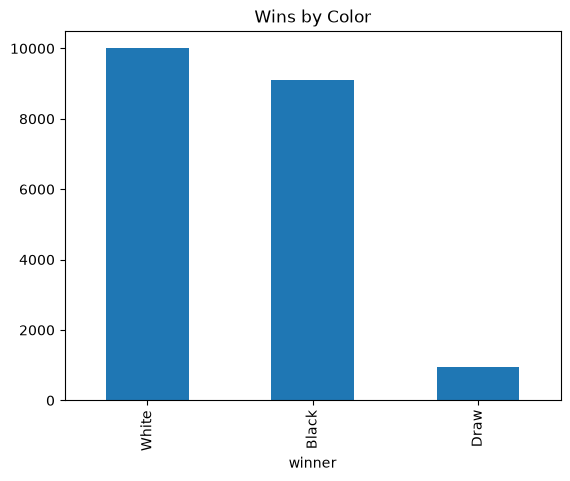

In [8]:
# ─────────────────────────────
# Q18 — Wins by color (bar chart)
# ─────────────────────────────
os.makedirs("../output", exist_ok=True)

win_counts = chess['winner'].value_counts()

plt.figure()
win_counts.plot(kind='bar')
plt.title("Wins by Color")
plt.savefig("../output/wins_by_color.png")
plt.show()


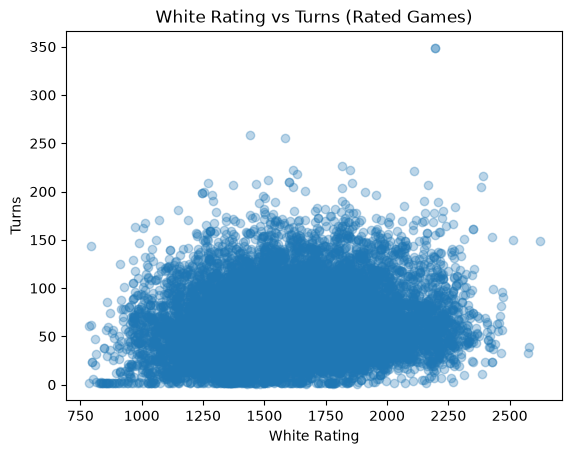

In [9]:
# ─────────────────────────────
# Q19 — Scatter: rating vs turns (rated games only)
# ─────────────────────────────
rated = merged[merged['rated'] == True]

plt.figure()
plt.scatter(rated['white_rating'], rated['turns'], alpha=0.3)
plt.title("White Rating vs Turns (Rated Games)")
plt.xlabel("White Rating")
plt.ylabel("Turns")
plt.savefig("../output/rating_vs_turns.png")
plt.show()

In [10]:
# ─────────────────────────────
# Results
# ─────────────────────────────
print("Q16 - Missing registry entries:", q16)
print("Q17 - Country inconsistencies:", q17)

Q16 - Missing registry entries: 15899
Q17 - Country inconsistencies: 29
